# Comprehensive End-to-End Customer Clustering Pipeline

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from math import pi
import warnings
warnings.filterwarnings('ignore')
print("Library OK!")

file_id = "1XtaKeD7b-la2R1ygFBNLj16VD1k0MB2Q"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.csv", quiet=False)
df = pd.read_csv("data.csv")

print(f"\n✓ Data loaded!")
print(f"✓ Shape: {df.shape[0]} customers, {df.shape[1]} features")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Library OK!


Downloading...
From: https://drive.google.com/uc?id=1XtaKeD7b-la2R1ygFBNLj16VD1k0MB2Q
To: /content/data.csv
100%|██████████| 1.01M/1.01M [00:00<00:00, 37.0MB/s]


✓ Data loaded!
✓ Shape: 8950 customers, 18 features

Columns: ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Data Exploration and Missing Value Handling


📊 Missing Values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

📊 Data Statistics:
        BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
count   8950.00            8950.00    8950.00           8950.00   
mean    1564.47               0.88    1003.20            592.44   
std     2081.53               0.24    2136.63           1659.89   
min        0.00               0.00       0.00              0.00   
25%      128.28               0.89      39.64              0.00   
50%      873.39               1.00     361.28             38.00   
75%     2054.14               1.00    1110.13            577.40   
max    19043.14               1.00   49039.57          40761.25   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count                 8950.00       8950.00              8950.00   
mean                   411.07        978.87                 0.49   
std                    904.34       2097.16                 0.40   
min                     

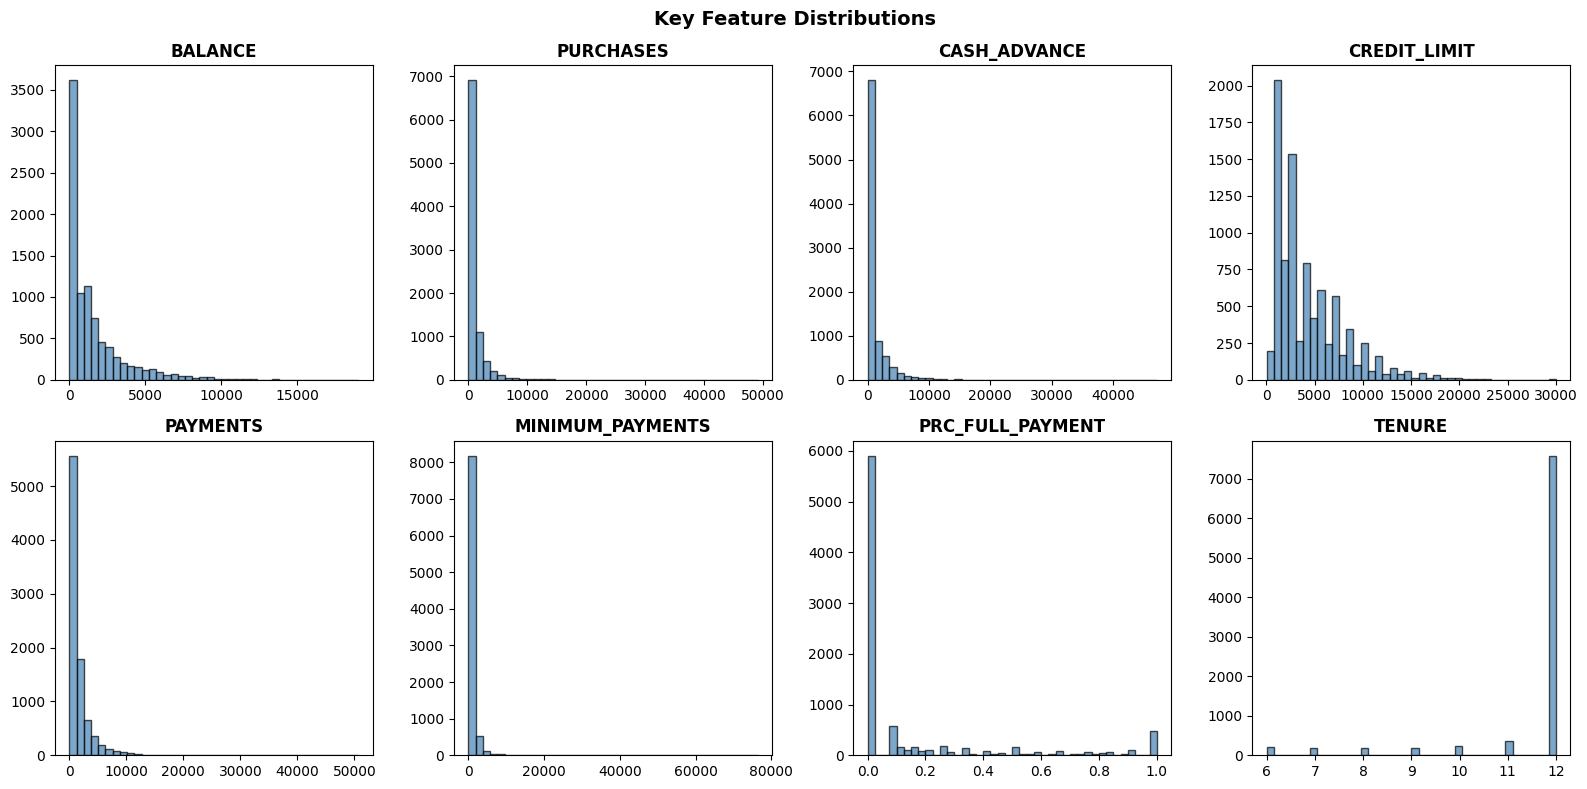

In [40]:
# Check missing values
print("\n📊 Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Statistics
print("\n📊 Data Statistics:")
print(df.describe().round(2))

# Handle missing values
df_clean = df.copy()
df_clean['MINIMUM_PAYMENTS'].fillna(df_clean['MINIMUM_PAYMENTS'].median(), inplace=True)
df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].median(), inplace=True)

print(f"\n✓ Missing values filled with median")
print(f"✓ Remaining nulls: {df_clean.isnull().sum().sum()}")

# Visualize distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
            'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
for i, col in enumerate(key_cols):
    axes[i//4, i%4].hist(df_clean[col], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i//4, i%4].set_title(col, fontweight='bold')
plt.suptitle('Key Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Outlier Handling and Feature Engineering

In [41]:
# Get numeric columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'CUST_ID' in num_cols: num_cols.remove('CUST_ID')

# Cap outliers using IQR
df_out = df_clean.copy()
print("\n📊 Outliers Detected & Capped (IQR method):")
for col in num_cols:
    Q1, Q3 = df_out[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = ((df_out[col] < lower) | (df_out[col] > upper)).sum()
    if outliers > 100:
        print(f"  {col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")
    df_out[col] = df_out[col].clip(lower=lower, upper=upper)

# Feature Engineering
df_feat = df_out.copy()
eps = 1e-6

df_feat['CREDIT_UTILIZATION'] = df_feat['BALANCE'] / (df_feat['CREDIT_LIMIT'] + eps)
df_feat['PAYMENT_RATIO'] = df_feat['PAYMENTS'] / (df_feat['PURCHASES'] + eps)
df_feat['CASH_ADVANCE_RATIO'] = df_feat['CASH_ADVANCE'] / (df_feat['PURCHASES'] + df_feat['CASH_ADVANCE'] + eps)
df_feat['ONEOFF_RATIO'] = df_feat['ONEOFF_PURCHASES'] / (df_feat['ONEOFF_PURCHASES'] + df_feat['INSTALLMENTS_PURCHASES'] + eps)
df_feat['AVG_PURCHASE_AMT'] = df_feat['PURCHASES'] / (df_feat['PURCHASES_TRX'] + eps)
df_feat['MONTHLY_SPENDING'] = df_feat['PURCHASES'] / (df_feat['TENURE'] + eps)
df_feat['PAYMENT_DISCIPLINE'] = df_feat['PRC_FULL_PAYMENT']*0.5 + (1-df_feat['CREDIT_UTILIZATION'].clip(0,1))*0.5

df_feat.replace([np.inf, -np.inf], 0, inplace=True)

print("\n✓ Created 7 new features:")
print("  CREDIT_UTILIZATION, PAYMENT_RATIO, CASH_ADVANCE_RATIO, ONEOFF_RATIO,")
print("  AVG_PURCHASE_AMT, MONTHLY_SPENDING, PAYMENT_DISCIPLINE")


📊 Outliers Detected & Capped (IQR method):
  BALANCE: 695 outliers (7.8%)
  BALANCE_FREQUENCY: 1493 outliers (16.7%)
  PURCHASES: 808 outliers (9.0%)
  ONEOFF_PURCHASES: 1013 outliers (11.3%)
  INSTALLMENTS_PURCHASES: 867 outliers (9.7%)
  CASH_ADVANCE: 1030 outliers (11.5%)
  ONEOFF_PURCHASES_FREQUENCY: 782 outliers (8.7%)
  CASH_ADVANCE_FREQUENCY: 525 outliers (5.9%)
  CASH_ADVANCE_TRX: 804 outliers (9.0%)
  PURCHASES_TRX: 766 outliers (8.6%)
  CREDIT_LIMIT: 248 outliers (2.8%)
  PAYMENTS: 808 outliers (9.0%)
  MINIMUM_PAYMENTS: 909 outliers (10.2%)
  PRC_FULL_PAYMENT: 1474 outliers (16.5%)
  TENURE: 1366 outliers (15.3%)

✓ Created 7 new features:
  CREDIT_UTILIZATION, PAYMENT_RATIO, CASH_ADVANCE_RATIO, ONEOFF_RATIO,
  AVG_PURCHASE_AMT, MONTHLY_SPENDING, PAYMENT_DISCIPLINE


# Feature Scaling and Dimensionality Reduction


✓ Scaled 24 features using RobustScaler

✓ PCA Results:
  Original dimensions: 24
  Reduced dimensions: 1
  Variance retained: 100.00%


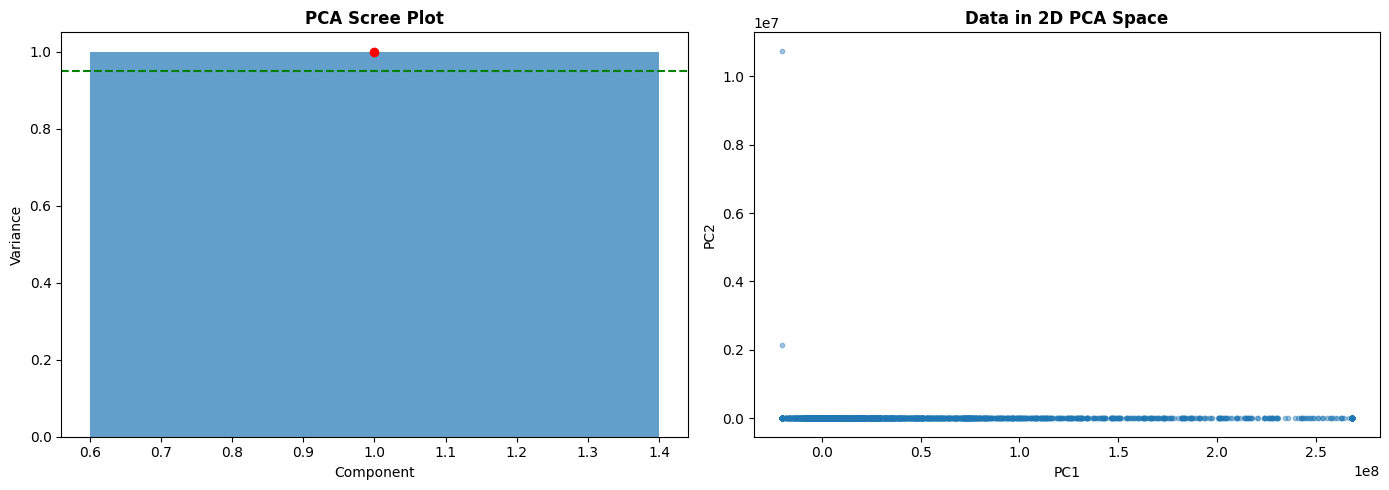

In [42]:
# Select features
feature_cols = [c for c in df_feat.columns if c != 'CUST_ID']
X = df_feat[feature_cols].values

# Scale
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
print(f"\n✓ Scaled {len(feature_cols)} features using RobustScaler")

# PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"\n✓ PCA Results:")
print(f"  Original dimensions: {X_scaled.shape[1]}")
print(f"  Reduced dimensions: {X_pca.shape[1]}")
print(f"  Variance retained: {pca.explained_variance_ratio_.sum():.2%}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
axes[0].plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), 'ro-')
axes[0].axhline(y=0.95, color='g', linestyle='--')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance')
axes[0].set_title('PCA Scree Plot', fontweight='bold')

axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.4, s=10)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('Data in 2D PCA Space', fontweight='bold')
plt.tight_layout()
plt.show()

# Determine Optional Cluster


✓ OPTIMAL K = 10 (based on Silhouette Score: 0.9040)


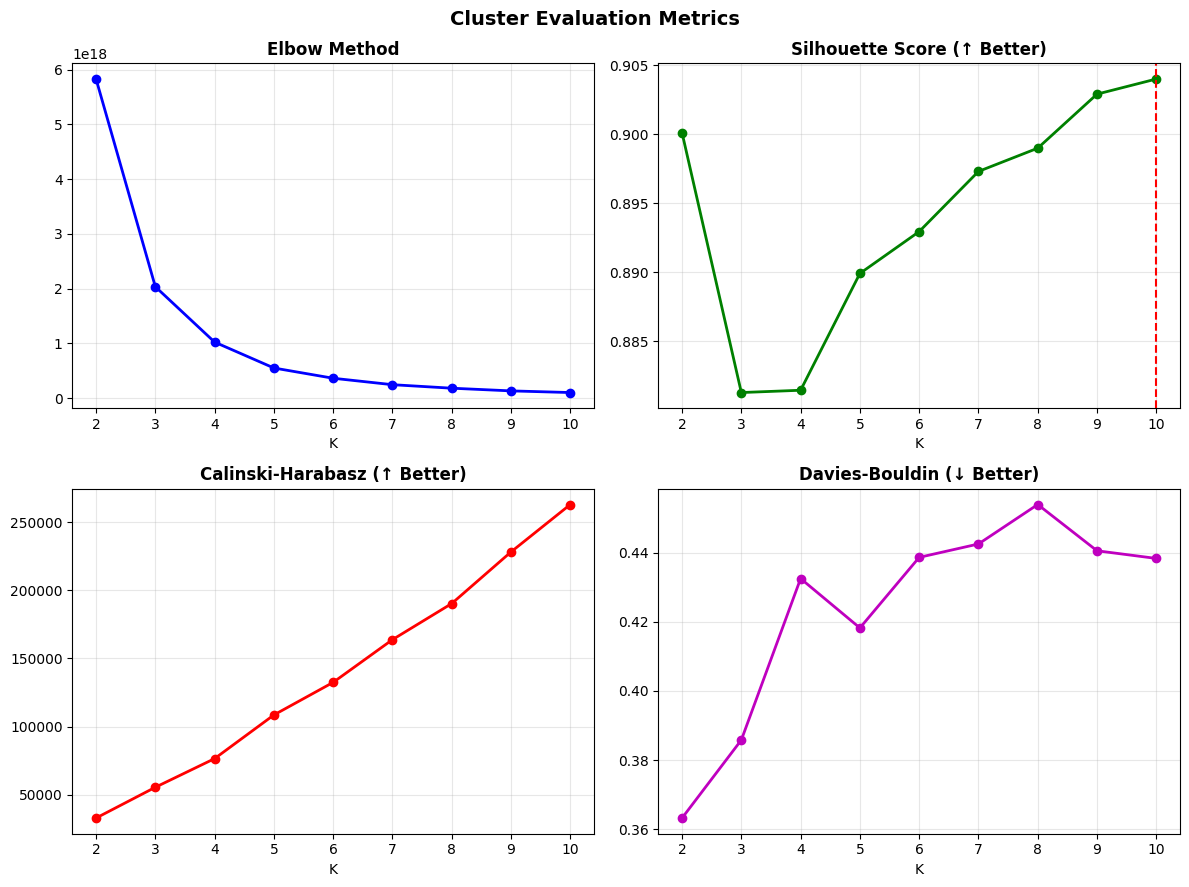

In [43]:
K_range = range(2, 11)
metrics = {'k': [], 'inertia': [], 'silhouette': [], 'calinski': [], 'davies_bouldin': []}

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    metrics['k'].append(k)
    metrics['inertia'].append(km.inertia_)
    metrics['silhouette'].append(silhouette_score(X_pca, labels))
    metrics['calinski'].append(calinski_harabasz_score(X_pca, labels))
    metrics['davies_bouldin'].append(davies_bouldin_score(X_pca, labels))

opt_k = metrics['k'][np.argmax(metrics['silhouette'])]
print(f"\n✓ OPTIMAL K = {opt_k} (based on Silhouette Score: {max(metrics['silhouette']):.4f})")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0,0].plot(K_range, metrics['inertia'], 'bo-', lw=2)
axes[0,0].set_title('Elbow Method', fontweight='bold'); axes[0,0].set_xlabel('K'); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(K_range, metrics['silhouette'], 'go-', lw=2)
axes[0,1].axvline(x=opt_k, color='r', linestyle='--')
axes[0,1].set_title('Silhouette Score (↑ Better)', fontweight='bold'); axes[0,1].set_xlabel('K'); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(K_range, metrics['calinski'], 'ro-', lw=2)
axes[1,0].set_title('Calinski-Harabasz (↑ Better)', fontweight='bold'); axes[1,0].set_xlabel('K'); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(K_range, metrics['davies_bouldin'], 'mo-', lw=2)
axes[1,1].set_title('Davies-Bouldin (↓ Better)', fontweight='bold'); axes[1,1].set_xlabel('K'); axes[1,1].grid(alpha=0.3)

plt.suptitle('Cluster Evaluation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_metrics.png', dpi=300)
plt.show()

OPTIMAL_K = opt_k

# Apply Clustering Algorithm


🔷 K-MEANS (K=10):
   Silhouette: 0.9040
   Calinski-Harabasz: 262889.10

🔷 HIERARCHICAL (K=10):
   Silhouette: 0.8984
   Calinski-Harabasz: 210051.69

🔷 DBSCAN (eps=142574.44):
   Clusters found: 80, Noise: 745


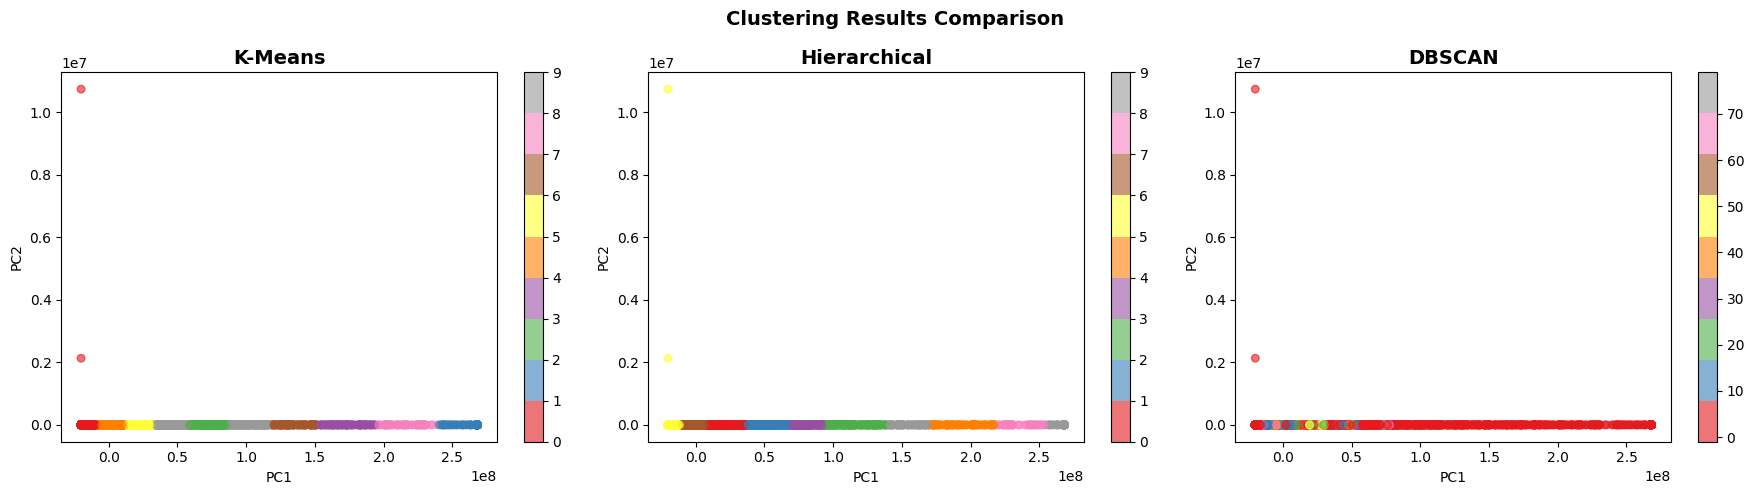

In [44]:
# K-Means
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_pca)
print(f"\n🔷 K-MEANS (K={OPTIMAL_K}):")
print(f"   Silhouette: {silhouette_score(X_pca, km_labels):.4f}")
print(f"   Calinski-Harabasz: {calinski_harabasz_score(X_pca, km_labels):.2f}")

# Hierarchical
hier = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_labels = hier.fit_predict(X_pca)
print(f"\n🔷 HIERARCHICAL (K={OPTIMAL_K}):")
print(f"   Silhouette: {silhouette_score(X_pca, hier_labels):.4f}")
print(f"   Calinski-Harabasz: {calinski_harabasz_score(X_pca, hier_labels):.2f}")

# DBSCAN
nn = NearestNeighbors(n_neighbors=5).fit(X_pca)
distances = np.sort(nn.kneighbors(X_pca)[0][:, 4])
eps_val = np.percentile(distances, 90)
dbscan = DBSCAN(eps=eps_val, min_samples=5)
db_labels = dbscan.fit_predict(X_pca)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"\n🔷 DBSCAN (eps={eps_val:.2f}):")
print(f"   Clusters found: {n_clusters_db}, Noise: {(db_labels==-1).sum()}")

# Visualize all methods
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, labels, title in zip(axes, [km_labels, hier_labels, db_labels],
                              ['K-Means', 'Hierarchical', 'DBSCAN']):
    scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels, cmap='Set1', alpha=0.6, s=30)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax)
plt.suptitle('Clustering Results Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=300)
plt.show()

final_labels = km_labels  # Use K-Means as final

# HIERARCHICAL CLUSTERING DENDROGRAM    

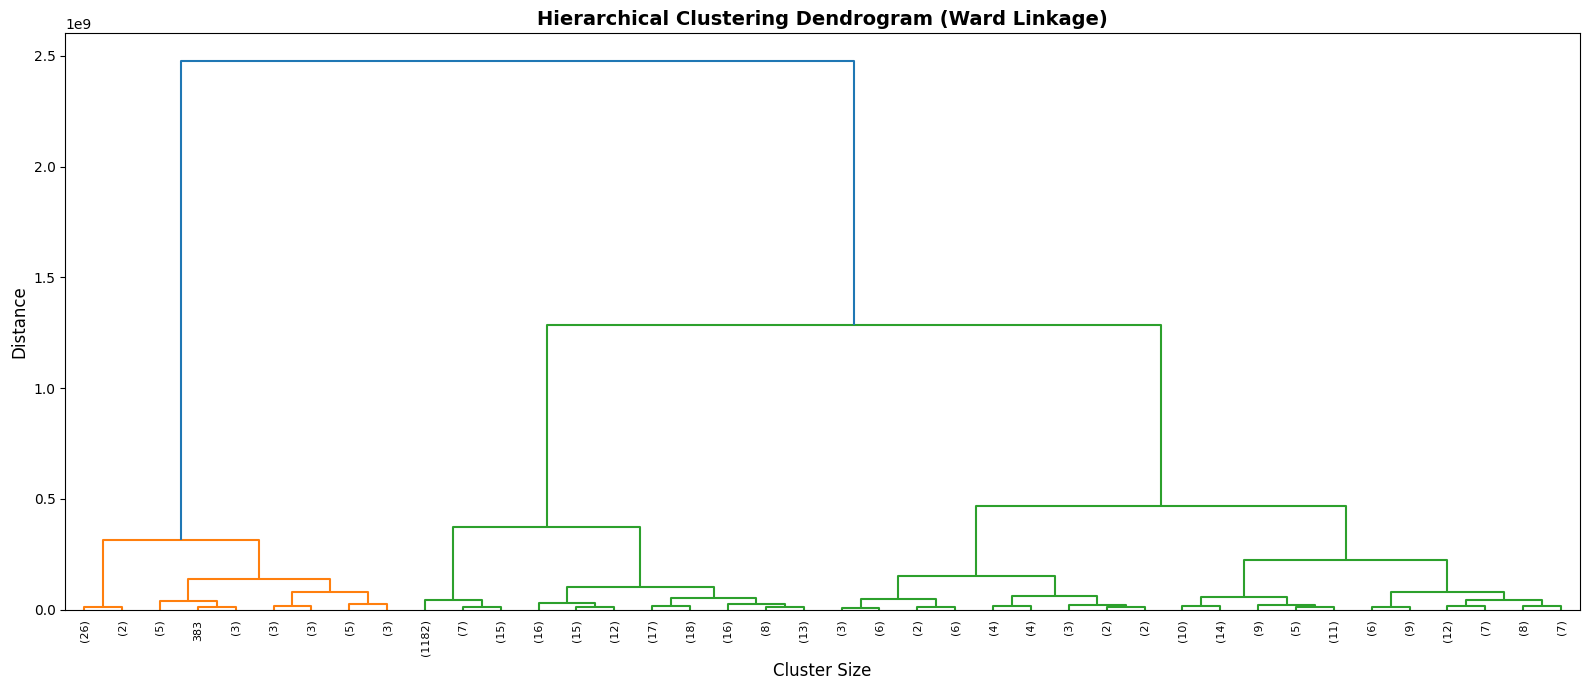

✓ Dendrogram shows cluster hierarchy and potential cut points


In [45]:
# Sample for dendrogram
n_sample = min(1500, len(X_pca))
idx = np.random.choice(len(X_pca), n_sample, replace=False)

plt.figure(figsize=(16, 7))
Z = linkage(X_pca[idx], method='ward')
dendrogram(Z, truncate_mode='lastp', p=40, show_leaf_counts=True,
           leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontweight='bold', fontsize=14)
plt.xlabel('Cluster Size', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=300)
plt.show()
print("✓ Dendrogram shows cluster hierarchy and potential cut points")

# CLUSTER PROFILING  

In [46]:
df_clustered = df_feat.copy()
df_clustered['Cluster'] = final_labels

# Cluster distribution
print("\n📊 Cluster Distribution:")
for c in sorted(df_clustered['Cluster'].unique()):
    n = (df_clustered['Cluster'] == c).sum()
    print(f"   Cluster {c}: {n:,} customers ({n/len(df_clustered)*100:.1f}%)")

# Profile features
profile_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS',
                'PRC_FULL_PAYMENT', 'TENURE', 'PURCHASES_TRX', 'CASH_ADVANCE_TRX',
                'CREDIT_UTILIZATION', 'CASH_ADVANCE_RATIO', 'MONTHLY_SPENDING', 'PAYMENT_DISCIPLINE']
profile_cols = [c for c in profile_cols if c in df_clustered.columns]

cluster_profiles = df_clustered.groupby('Cluster')[profile_cols].mean()
print("\n📊 Cluster Profiles (Mean Values):")
print(cluster_profiles.round(2).T.to_string())

# Save
cluster_profiles.to_csv('cluster_profiles.csv')
df_clustered.to_csv('clustered_customers.csv', index=False)
print("\n✓ Saved: cluster_profiles.csv, clustered_customers.csv")


📊 Cluster Distribution:
   Cluster 0: 7,076 customers (79.1%)
   Cluster 1: 205 customers (2.3%)
   Cluster 2: 206 customers (2.3%)
   Cluster 3: 81 customers (0.9%)
   Cluster 4: 493 customers (5.5%)
   Cluster 5: 374 customers (4.2%)
   Cluster 6: 92 customers (1.0%)
   Cluster 7: 59 customers (0.7%)
   Cluster 8: 127 customers (1.4%)
   Cluster 9: 237 customers (2.6%)

📊 Cluster Profiles (Mean Values):
Cluster                   0        1        2        3        4        5        6        7        8        9
BALANCE             1214.94  2599.85  2954.92  2290.14  1186.73  1831.46  2453.19  2144.50  2488.33  2458.59
PURCHASES            932.38     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
CASH_ADVANCE         472.25  2438.14  1628.08  2170.88   884.92  1015.43  2099.95  2090.80  1812.24  1279.10
CREDIT_LIMIT        4494.84  6869.59  5273.30  5247.53  2257.20  3313.77  5991.85  4388.98  5039.37  4319.83
PAYMENTS            1337.73  4148.30  1343.86

# CLUSTER VISUALIZATION (HEATMAP & RADAR CHART)    

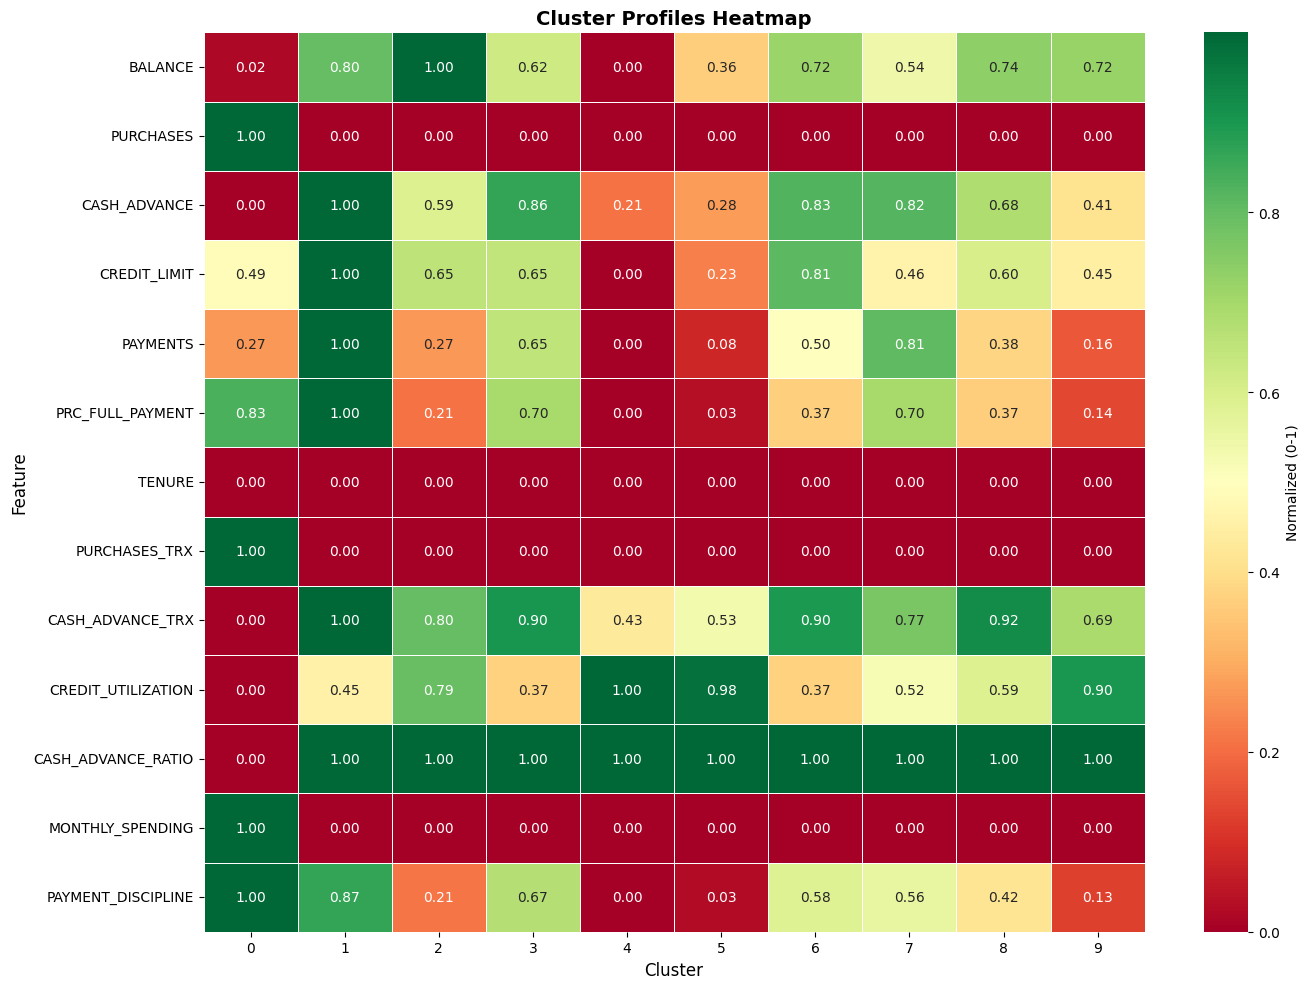

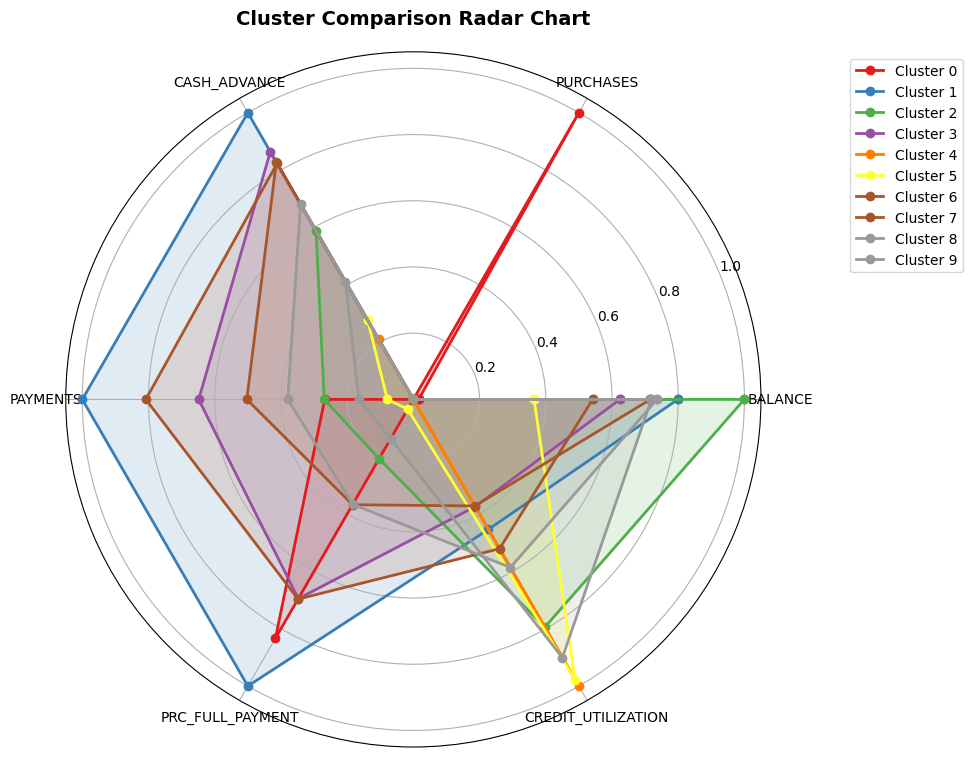

In [47]:
# Normalize for visualization
norm_profiles = cluster_profiles.copy()
for col in norm_profiles.columns:
    min_v, max_v = norm_profiles[col].min(), norm_profiles[col].max()
    norm_profiles[col] = (norm_profiles[col] - min_v) / (max_v - min_v + 1e-6)

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(norm_profiles.T, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5,
            cbar_kws={'label': 'Normalized (0-1)'})
plt.title('Cluster Profiles Heatmap', fontweight='bold', fontsize=14)
plt.xlabel('Cluster', fontsize=12); plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=300)
plt.show()

# Radar Chart
radar_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS', 'PRC_FULL_PAYMENT', 'CREDIT_UTILIZATION']
radar_cols = [c for c in radar_cols if c in norm_profiles.columns]
N = len(radar_cols)
angles = [n/N * 2 * pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = plt.cm.Set1(np.linspace(0, 1, len(norm_profiles)))
for i, (cluster, row) in enumerate(norm_profiles[radar_cols].iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, 'o-', lw=2, label=f'Cluster {cluster}', color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_cols, fontsize=10)
ax.set_title('Cluster Comparison Radar Chart', fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.savefig('cluster_radar.png', dpi=300)
plt.show()


# CLUSTER INTERPRETATION



In [54]:
# ============================================================================
# INTERPRETATION LOGIC EXPLANATION:
# ============================================================================
# This function analyzes each cluster's average behavior and assigns:
#   1. A descriptive NAME (e.g., "VIP Customer", "Revolver")
#   2. TRAITS that describe spending, payment, and usage patterns
#
# THRESHOLDS USED (compared against FULL DATASET, not just cluster means):
#   - Top 15% (quantile 0.85) = "High" category
#   - Bottom 15% (quantile 0.15) = "Low" category
#   - Values in between = "Moderate/Standard"
# ============================================================================

def interpret_cluster(profiles, full_data):
    """
    Analyzes cluster profiles and returns interpretations.

    Input:
        profiles (DataFrame) - Mean values of features per cluster
        full_data (DataFrame) - Original full dataset for accurate quantiles
    Output: Dictionary with cluster names and behavioral traits
    """
    interpretations = {}

    # Calculate quantiles from FULL DATASET (not cluster means)
    purchases_q85 = full_data['PURCHASES'].quantile(0.85)
    purchases_q15 = full_data['PURCHASES'].quantile(0.15)
    purchases_median = full_data['PURCHASES'].median()

    purchases_trx_q85 = full_data['PURCHASES_TRX'].quantile(0.85)
    purchases_trx_q15 = full_data['PURCHASES_TRX'].quantile(0.15)

    balance_q85 = full_data['BALANCE'].quantile(0.85)
    balance_q15 = full_data['BALANCE'].quantile(0.15)

    for cluster in profiles.index:
        p = profiles.loc[cluster]  # Get this cluster's profile (mean values)
        traits = []
        name = "Standard User"

        # ──────────────────────────────────────────────────────────
        # 1. SPENDING ANALYSIS (based on PURCHASES amount)
        # ──────────────────────────────────────────────────────────
        # Compare cluster's avg purchases to FULL DATASET quantiles
        if p['PURCHASES'] >= purchases_q85:
            traits.append(f"🛒 High spender (avg ${p['PURCHASES']:,.0f} >= top 15%: ${purchases_q85:,.0f})")
        elif p['PURCHASES'] <= purchases_q15:
            traits.append(f"🛒 Low spender (avg ${p['PURCHASES']:,.0f} <= bottom 15%: ${purchases_q15:,.0f})")
        else:
            traits.append(f"🛒 Moderate spender (avg ${p['PURCHASES']:,.0f})")

        # ──────────────────────────────────────────────────────────
        # 2. CASH ADVANCE BEHAVIOR
        # ──────────────────────────────────────────────────────────
        # Cash advance ratio > 40% means they rely heavily on cash withdrawals
        cash_ratio = p.get('CASH_ADVANCE_RATIO', 0)
        if cash_ratio > 0.4:
            traits.append(f"💵 Heavy cash advance user ({cash_ratio*100:.1f}% of credit usage)")
            name = "Cash Advance Dependent"
        elif cash_ratio > 0.1:
            traits.append(f"💵 Moderate cash advance user ({cash_ratio*100:.1f}% of credit usage)")
        else:
            traits.append(f"💵 Rarely uses cash advance ({cash_ratio*100:.1f}% of credit usage)")

        # ──────────────────────────────────────────────────────────
        # 3. PAYMENT BEHAVIOR (how they pay their bills)
        # ──────────────────────────────────────────────────────────
        # PRC_FULL_PAYMENT = percentage of months they paid full balance
        prc_full = p['PRC_FULL_PAYMENT']
        if prc_full > 0.5:
            traits.append(f"✅ Pays full balance often ({prc_full*100:.1f}% of months)")
            # If high spender + pays full = Responsible; else = Light User
            if p['PURCHASES'] > purchases_median:
                name = "Responsible Transactor"
            else:
                name = "Light User"
        elif prc_full < 0.1:
            traits.append(f"🔄 Revolving balance - rarely pays full ({prc_full*100:.1f}% of months)")
            name = "Revolver"
        else:
            traits.append(f"🔄 Sometimes pays full balance ({prc_full*100:.1f}% of months)")

        # ──────────────────────────────────────────────────────────
        # 4. CREDIT UTILIZATION (balance / credit limit)
        # ──────────────────────────────────────────────────────────
        # High utilization (>60%) = risky; Low (<20%) = conservative
        credit_util = p['CREDIT_UTILIZATION']
        if credit_util > 0.6:
            traits.append(f"⚠️ High credit utilization ({credit_util*100:.1f}% of limit used)")
        elif credit_util < 0.2:
            traits.append(f"✅ Low credit utilization ({credit_util*100:.1f}% of limit used)")
        else:
            traits.append(f"📊 Moderate credit utilization ({credit_util*100:.1f}% of limit used)")

        # ──────────────────────────────────────────────────────────
        # 5. TRANSACTION FREQUENCY
        # ──────────────────────────────────────────────────────────
        # How often they make purchases (compared to full dataset)
        purch_trx = p['PURCHASES_TRX']
        if purch_trx >= purchases_trx_q85:
            traits.append(f"📈 Frequent transactor ({purch_trx:.1f} avg transactions >= top 15%)")
            # High spender + Frequent transactor = VIP
            if p['PURCHASES'] >= purchases_q85:
                name = "VIP Customer"
        elif purch_trx <= purchases_trx_q15:
            traits.append(f"📉 Infrequent user ({purch_trx:.1f} avg transactions <= bottom 15%)")
            # Low transactions + Low spending = Inactive
            if p['PURCHASES'] <= purchases_q15:
                name = "Inactive/Dormant"
        else:
            traits.append(f"📊 Moderate transaction frequency ({purch_trx:.1f} avg transactions)")

        # ──────────────────────────────────────────────────────────
        # 6. BALANCE LEVEL
        # ──────────────────────────────────────────────────────────
        balance = p['BALANCE']
        if balance >= balance_q85:
            traits.append(f"💰 High balance carrier (avg ${balance:,.0f} >= top 15%)")
        elif balance <= balance_q15:
            traits.append(f"💰 Low balance (avg ${balance:,.0f} <= bottom 15%)")
        else:
            traits.append(f"💰 Moderate balance (avg ${balance:,.0f})")

        # Store results
        interpretations[cluster] = {'name': name, 'traits': traits}

    return interpretations

# Run interpretation with FULL DATASET for accurate quantile comparison
interpretations = interpret_cluster(cluster_profiles, df_clustered)

# ============================================================================
# TRANSACTION STATISTICS TABLE
# ============================================================================
print("\n" + "="*70)
print("📊 TRANSACTION STATISTICS BY CLUSTER")
print("="*70)
print("""
This table shows transaction counts for each cluster:
  - Min: Lowest number of transactions by any customer in cluster
  - Max: Highest number of transactions (all-time high)
  - Total: Sum of all transactions in the cluster
  - Mean: Average transactions per customer
""")

trx_stats = df_clustered.groupby('Cluster').agg({
    'PURCHASES_TRX': ['min', 'max', 'sum', 'mean'],
    'CASH_ADVANCE_TRX': ['min', 'max', 'sum', 'mean']
}).round(2)

trx_stats.columns = ['Purch_Min', 'Purch_Max', 'Purch_Total', 'Purch_Mean',
                     'CashAdv_Min', 'CashAdv_Max', 'CashAdv_Total', 'CashAdv_Mean']
print(trx_stats.to_string())

# ============================================================================
# DETAILED CLUSTER INTERPRETATIONS
# ============================================================================
print("\n" + "="*70)
print("🎯 DETAILED CLUSTER INTERPRETATIONS")
print("="*70)
print("""
Each cluster below shows:
  1. Segment Name - A business-friendly label
  2. Size - Number and percentage of customers
  3. Transaction Stats - Min/Max/Total/Avg for purchases & cash advances
  4. Behavioral Traits - Key characteristics that define this segment
""")

for cluster, info in interpretations.items():
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster]
    n = len(cluster_data)

    # Calculate transaction statistics
    purch_min = cluster_data['PURCHASES_TRX'].min()
    purch_max = cluster_data['PURCHASES_TRX'].max()
    purch_total = cluster_data['PURCHASES_TRX'].sum()
    purch_mean = cluster_data['PURCHASES_TRX'].mean()

    cash_min = cluster_data['CASH_ADVANCE_TRX'].min()
    cash_max = cluster_data['CASH_ADVANCE_TRX'].max()
    cash_total = cluster_data['CASH_ADVANCE_TRX'].sum()
    cash_mean = cluster_data['CASH_ADVANCE_TRX'].mean()

    # Calculate payment statistics (excluding zeros for minimum)
    pay_max = cluster_data['PAYMENTS'].max()
    pay_total = cluster_data['PAYMENTS'].sum()
    pay_mean = cluster_data['PAYMENTS'].mean()
    # Get minimum non-zero payment
    non_zero_payments = cluster_data[cluster_data['PAYMENTS'] > 0]['PAYMENTS']
    pay_min_nonzero = non_zero_payments.min() if len(non_zero_payments) > 0 else 0

    # Print cluster details
    print(f"\n{'═'*65}")
    print(f"  CLUSTER {cluster}: '{info['name'].upper()}'")
    print(f"{'═'*65}")
    print(f"  📌 Size: {n:,} customers ({n/len(df_clustered)*100:.1f}% of total)")

    print(f"\n  📈 PURCHASE TRANSACTIONS:")
    print(f"     ├─ Minimum (lowest customer):  {purch_min:.0f} transactions")
    print(f"     ├─ Maximum (highest customer): {purch_max:.0f} transactions")
    print(f"     ├─ Total (all customers):      {purch_total:,.0f} transactions")
    print(f"     └─ Average per customer:       {purch_mean:.1f} transactions")

    print(f"\n  💵 CASH ADVANCE TRANSACTIONS:")
    print(f"     ├─ Minimum (lowest customer):  {cash_min:.0f} transactions")
    print(f"     ├─ Maximum (highest customer): {cash_max:.0f} transactions")
    print(f"     ├─ Total (all customers):      {cash_total:,.0f} transactions")
    print(f"     └─ Average per customer:       {cash_mean:.1f} transactions")

    print(f"\n  💳 PAYMENTS (Amount Paid Back):")
    print(f"     ├─ All-Time Low (excl. zero):  ${pay_min_nonzero:,.2f}")
    print(f"     ├─ All-Time High:              ${pay_max:,.2f}")
    print(f"     ├─ Total (all customers):      ${pay_total:,.2f}")
    print(f"     └─ Average per customer:       ${pay_mean:,.2f}")

    print(f"\n  🔍 BEHAVIORAL CHARACTERISTICS:")
    if info['traits']:
        for trait in info['traits']:
            print(f"     • {trait}")
    else:
        print(f"     • Moderate behavior across all metrics (no extreme patterns)")



📊 TRANSACTION STATISTICS BY CLUSTER

This table shows transaction counts for each cluster:
  - Min: Lowest number of transactions by any customer in cluster
  - Max: Highest number of transactions (all-time high)
  - Total: Sum of all transactions in the cluster
  - Mean: Average transactions per customer

         Purch_Min  Purch_Max  Purch_Total  Purch_Mean  CashAdv_Min  CashAdv_Max  CashAdv_Total  CashAdv_Mean
Cluster                                                                                                      
0                0         41       104029       14.70            0           10          12132          1.71
1                0          0            0        0.00            1           10           1322          6.45
2                0          0            0        0.00            1           10           1132          5.50
3                0          0            0        0.00            1           10            485          5.99
4                0          2  